In [ ]:
import yfinance as yf
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated,List
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
import requests
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,  tools_condition 
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,HumanMessage, AIMessage,SystemMessage,ToolMessage
import os 
import json
import re
from dotenv import load_dotenv

load_dotenv()  


True

In [69]:
@tool
def news_yfinance(ticker:str)->list:
    """
    Fetches and formats the latest news articles for a given stock ticker using the yfinance library.

    This function retrieves the raw news data for the specified ticker and extracts 
    key information into a clean, standardized dictionary format, safely handling 
    missing fields to prevent KeyErrors.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'TSLA').

    Returns:
        list: A list of dictionaries, where each dictionary represents a news article 
              and contains the following keys:
              - 'title' (str): The headline of the article.
              - 'summary' (str): A brief summary of the article.
              - 'published_at' (str): The publication date and time.
              - 'source' (str): The publisher or provider of the news.
              - 'url' (str): The canonical URL to the full article.
    """
    stock_news = yf.Ticker(ticker).news
    response = [] 
    for item in stock_news:
        content = item.get('content', {}) 
        clean_article = {
        "title": content.get('title', ''),
        "summary": content.get('summary', ''),
        "published_at": content.get('pubDate', ''),
        "source": content.get('provider', {}).get('displayName', 'Unknown'),
        "url": content.get('canonicalUrl', {}).get('url', '')
        }
        response.append(clean_article)

    return response

In [70]:
@tool
def earning_call(ticker: str)-> dict:
    """
    Fetches the latest earnings call data for a given stock ticker using the ROIC.ai API.
    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'MSFT', 'BRK').
    Returns:
        dict: A dictionary containing the parsed JSON response from the API, 
              which includes the latest earnings call details.

    Raises:
        requests.exceptions.RequestException: If there is an issue with the network request.
        ValueError: If the response payload is not valid JSON.
    """
    try:
        api_key = os.getenv("ROC_AI_API_KEY")
        if "." in ticker: 
            ticker=ticker.split(".")[0]
        response = requests.get(f"https://api.roic.ai/v2/company/earnings-calls/latest/{ticker}?apikey={api_key}")
        data = response.json()
        if data:
            return data   
    except Exception as e:
        return {"error": str(e)}

In [71]:
@tool
def get_earnings_history(ticker: str) -> dict:
    """Fetch earnings beat/miss history and EPS surprises. Free via yfinance.
    Consistent beats = bullish signal. Misses = bearish red flag."""
    try:
        stock    = yf.Ticker(ticker)
        earnings = stock.earnings_dates
 
        if earnings is None or earnings.empty:
            return {"error": f"No earnings data for {ticker}"}
 
        history = []
        for date, row in earnings.head(8).iterrows():
            eps_est    = row.get("EPS Estimate")
            eps_actual = row.get("Reported EPS")
            surprise   = row.get("Surprise(%)")
 
            history.append({
                "date":        str(date.date()) if hasattr(date, "date") else str(date),
                "eps_estimate": eps_est,
                "eps_actual":   eps_actual,
                "surprise_pct": surprise,
                "beat":         (surprise > 0) if surprise == surprise else None,
            })
 
        return {"ticker": ticker, "earnings_history": history, "source": "yfinance"}
 
    except Exception as e:
        return {"error": str(e)}

In [72]:
@tool
def get_insider_transactions(ticker: str) -> dict:
    """Fetch recent insider buying and selling activity. Free via yfinance.
    Heavy insider selling = bearish signal. Buying = bullish signal."""
    try:
        stock    = yf.Ticker(ticker)
        insider  = stock.insider_transactions
 
        if insider is None or insider.empty:
            return {"error": f"No insider data for {ticker}"}
 
        transactions = []
        for _, row in insider.head(10).iterrows():
            transactions.append({
                "insider":    row.get("Insider"),
                "relation":   row.get("Relation"),   
                "date":       str(row.get("Start Date", "")),
                "transaction":row.get("Transaction"), 
                "shares":     row.get("Shares"),
                "value":      row.get("Value"),
            })
 
        return {"ticker": ticker, "insider_transactions": transactions, "source": "yfinance"}
 
    except Exception as e:
        return {"error": str(e)}

In [73]:
llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct", # Or any other valid Groq identifier
    temperature=0.0,
    max_retries=2,
)
report_writer_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.0,
)

In [74]:
NewsSentiment_tools = [earning_call,news_yfinance,get_insider_transactions,get_earnings_history]
NewsSentiment_tool_node = ToolNode(NewsSentiment_tools)
NewsSentiment_llm = llm.bind_tools(NewsSentiment_tools)

In [75]:
class SentimentReport(BaseModel):
    ticker: str
    sentiment: str                  # "Bullish" | "Bearish" | "Neutral"
    sentiment_score: float          # -1.0 to 1.0
    earnings_call_summary: str
    earnings_surprise_trend: str
    insider_signal: str             # "Bullish" | "Bearish" | "Neutral"
    insider_summary: str
    news_summary: str
    key_events: List[str]
    red_flags: List[str]
    confidence: float
    sources: List[str]

In [76]:
class NewsSentimentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    ticker: str
    result: str

In [77]:
def NewsSentimentAgent(state:NewsSentimentState)->NewsSentimentState:
    response = NewsSentiment_llm.invoke(state["messages"])
    return {"messages": [response]}


In [78]:
def extract_tool_data(messages: list) -> str:
    """Extract tool results as plain text with truncation to stay under token limits."""
    
    # Max chars per tool — keeps total well under 12k tokens
    LIMITS = {
        "earning_call":              2000,  # transcripts are huge, trim hard
        "news_yfinance":             1500,  # headlines + summaries
        "get_earnings_history":      500,   # small structured data, keep all
        "get_insider_transactions":  500,   # small structured data, keep all
    }
    DEFAULT_LIMIT = 800

    parts = []
    for msg in messages:
        if isinstance(msg, ToolMessage):
            limit = LIMITS.get(msg.name, DEFAULT_LIMIT)
            content = msg.content[:limit]  # truncate
            parts.append(f"[{msg.name}]\n{content}")

    return "\n\n".join(parts)

def parse_json_response(content: str) -> dict:
    """Strip markdown fences if present, then parse JSON."""
    match = re.search(r"```(?:json)?\s*(.*?)\s*```", content, re.DOTALL)
    if match:
        content = match.group(1)
    return json.loads(content.strip())

In [79]:
REPORT_SYSTEM_PROMPT = """You are a financial sentiment analyst. Based on the tool data provided, return ONLY this JSON:
 
{
  "ticker": str,
  "sentiment": "Bullish" | "Bearish" | "Neutral",
  "sentiment_score": float (-1.0 very bearish to 1.0 very bullish),
  "earnings_call_summary": str (2-3 sentences on management tone and guidance),
  "earnings_surprise_trend": str (e.g. "Beat 6 of last 8 quarters, avg surprise +4.2%"),
  "insider_signal": "Bullish" | "Bearish" | "Neutral",
  "insider_summary": str (who is buying/selling, total value, roles),
  "news_summary": str (2-3 sentences on dominant news narrative),
  "key_events": [str],
  "red_flags": [str],
  "confidence": float (0 to 1, based on data completeness),
  "sources": [str]
}
 
Scoring guide for sentiment_score:
- Strong earnings beat + raised guidance  → +0.3
- Consistent EPS beats (5+/8)            → +0.2
- CEO/CFO buying shares                  → +0.2
- Positive news narrative                → +0.2
- Missed earnings / lowered guidance     → -0.3
- Heavy insider selling by executives   → -0.2
- Negative news (lawsuits, recalls)      → -0.2
 
Return ONLY valid JSON. No markdown fences, no explanation outside it."""

In [80]:
def report_node(state: NewsSentimentState):
    """
    Report-writing LLM — receives ONLY plain text tool data.
    Builds a clean 2-message conversation so the API never
    sees tool_use/tool_result blocks → no BadRequestError.
    """
    raw_data = extract_tool_data(state["messages"])
 
    clean_messages = [
        SystemMessage(content=REPORT_SYSTEM_PROMPT),
        HumanMessage(content=f"Here is the collected sentiment data:\n\n{raw_data}"),
    ]
 
    response = report_writer_llm.invoke(clean_messages)
    return {"messages": [response]}

In [81]:
graph = StateGraph(NewsSentimentState)
graph.add_node("NewsSentimentAgent",NewsSentimentAgent)
graph.add_node("NewsSentimentTools",NewsSentiment_tool_node)
graph.add_node("ReportWriter",report_node)

graph.add_edge(START,"NewsSentimentAgent")
graph.add_conditional_edges("NewsSentimentAgent",tools_condition,{"tools": "NewsSentimentTools",END:"ReportWriter" })
graph.add_edge("NewsSentimentTools","NewsSentimentAgent")
graph.add_edge("ReportWriter",END)

workflow=graph.compile()

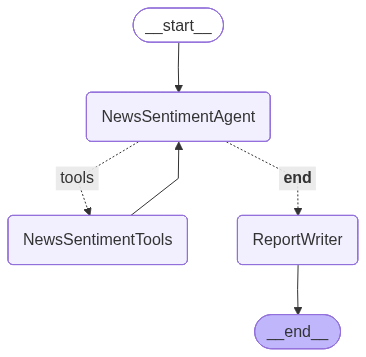

In [82]:
workflow

In [83]:
NewsSentiment_SYS_PROMPT = """You are a financial sentiment analyst. Analyze market sentiment for a stock ticker by calling ALL tools in this exact sequence:

STEP 1 — EARNINGS CALL: Call `earning_call` to get management's latest transcript.
Extract: tone (confident/cautious), forward guidance, any raised/lowered targets.

STEP 2 — EARNINGS HISTORY: Call `get_earnings_history` to get the last 8 quarters of EPS surprises.
Extract: how many beats vs misses, trend direction, average surprise %.

STEP 3 — INSIDER ACTIVITY: Call `get_insider_transactions` to get recent insider trades.
Extract: are insiders buying or selling? What roles (CEO, CFO)? Total value.

STEP 4 — NEWS HEADLINES: Call `news_yfinance` to get recent articles and their URLs.
Extract: headline themes, which 2-3 articles look most market-moving.

STEP 5 — Then send it to next node report node

RULES:
- Call ALL 4 tools before forming any conclusion.
- Never hallucinate metrics. Only use data from tool results.
- If a tool returns an error, note it and continue to the next step.
"""

In [84]:
def run_news_and_sentiment_agent (ticker:str) -> str:
    """
    Kicks off the LangGraph workflow for news and sentiment analysis.
    """
    # Initialize the state with the System Prompt and the Human's request
    initial_state = {
        "messages": [
            SystemMessage(content=NewsSentiment_SYS_PROMPT),
            HumanMessage(content=f"Analyze the current news and earnings sentiment for ticker: {ticker}")
        ],
        "ticker": ticker,
        "result": ""
    }
    
    # Run the graph
    final_state = workflow.invoke(initial_state)
    
    message = final_state["messages"][-1].content

    finalmessage = parse_json_response(message)

    return finalmessage



In [85]:
a=run_news_and_sentiment_agent("AAPL")

In [86]:
a

{'ticker': 'AAPL',
 'sentiment': 'Bullish',
 'sentiment_score': 0.4,
 'earnings_call_summary': "Apple's CEO Tim Cook discussed the company's transition and quarterly results, with CFO Kevan Parekh providing additional remarks. The company reported a strong earnings beat, with a surprise percentage of 3.46%. The management tone was positive, with a focus on future business outlook.",
 'earnings_surprise_trend': 'Beat 2 of last 3 quarters, avg surprise +4.9%',
 'insider_signal': 'Neutral',
 'insider_summary': 'Insider transactions show mixed activity, with some insiders buying and others selling shares. The total value of transactions is approximately $34236.',
 'news_summary': 'Apple is planning a major change to its Mac chip roadmap, shifting focus toward AI-focused M7 chips. The company is also one of the 15 Best AI Stocks That Will Make You Rich in 10 Years.',
 'key_events': ['Earnings report', 'Mac chip roadmap shift'],
 'red_flags': [],
 'confidence': 0.8,
 'sources': ['Yahoo Finan